# **03 - Machine Learning**

## Objectives

- Prepare the cleaned retail data for machine learning.
- Define an appropriate machine learning problem based on the exploratory analysis.
- Select and justify a suitable algorithm.
- Train and evaluate the model using appropriate performance metrics.
- Interpret the model results and assess its usefulness for the business.
- Identify limitations and potential improvements.

## Inputs

- Cleaned Online Retail Transaction dataset produced during the ETL process and explored during EDA.

## Outputs

- A trained and evaluated machine learning model.
- Model performance metrics and visualisations.
- Interpretation of the model results and their business relevance.

## Additional Comments

- The modelling approach will be selected based on the business problem and characteristics identified during exploratory analysis.

---

# Change working directory

In [1]:
import os

current_dir = os.getcwd()
print("Current directory:", current_dir)

if os.path.basename(current_dir) == "jupyter_notebooks":
    os.chdir(os.path.dirname(current_dir))
elif os.path.basename(current_dir) == "vscode-projects":
    os.chdir("Online Retail Transaction Analysis")

current_dir = os.getcwd()
print("Working directory set to:", current_dir)

Current directory: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis/jupyter_notebooks
Working directory set to: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis


---

# Section 1 -  Import libraries

Here I will be importing the libraries that I will be using in this notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

---

# Section 2 - Load the dataset

The cleaned Online Retail dataset produced during the ETL stage will be loaded for the machine learning analysis. I will first inspect the dataset to confirm that it has loaded correctly before preparing the data for modelling.

In [3]:
df = pd.read_csv(
    "outputs/online_retail_cleaned.csv",
    dtype={"InvoiceNo": str},
    parse_dates=["InvoiceDate"],
)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
df.shape

(524878, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   524878 non-null  int64         
 7   Country      524878 non-null  object        
 8   Revenue      524878 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 36.0+ MB


The cleaned dataset contains 524,878 rows and 9 columns, with no missing values. The data types have also loaded as expected, including `InvoiceDate` as a datetime.

This confirms that the cleaned dataset has loaded correctly and is ready to be prepared for the machine learning analysis.

---

# Section 3 - Define the Machine Learning Problem

The exploratory analysis identified differences in customer purchasing behaviour. Customers varied in how frequently they made purchases and in the total revenue they generated. The analysis also showed that high average transaction values could sometimes be influenced by a small number of unusually large purchases.

Based on these findings, customer segmentation was selected as the machine learning problem. The aim is to identify groups of customers with similar purchasing behaviours using Recency, Frequency and Monetary (RFM) measures.

As the dataset does not contain predefined customer segment labels, this is an unsupervised machine learning problem. K-Means clustering will be used to group customers based on similarities in their RFM characteristics.

---

# Section 4 - Create RFM Features

To prepare the data for customer segmentation, Recency, Frequency and Monetary (RFM) features will be created for each customer.

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique transactions made by the customer.
- **Monetary:** Total revenue generated by the customer.

A reference date one day after the latest transaction in the dataset will be used to calculate Recency.

In [7]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

The dataset will now be grouped by `CustomerID` to calculate each customer's Recency, Frequency and Monetary values.

In [8]:
customer_last_purchase = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
customer_last_purchase

,CustomerID,InvoiceDate
0,12346,2011-01-18 10:01:00
1,12347,2011-12-07 15:52:00
2,12348,2011-09-25 13:13:00
3,12349,2011-11-21 09:51:00
4,12350,2011-02-02 16:01:00
...,...,...
4333,18280,2011-03-07 09:52:00
4334,18281,2011-06-12 10:53:00
4335,18282,2011-12-02 11:43:00
4336,18283,2011-12-06 12:02:00


In [ ]:
customer_last_purchase["Recency"] = (
    reference_date - customer_last_purchase["InvoiceDate"]
).dt.days
customer_last_purchase

,CustomerID,InvoiceDate,Recency
0,12346,2011-01-18 10:01:00,326
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310
...,...,...,...
4333,18280,2011-03-07 09:52:00,278
4334,18281,2011-06-12 10:53:00,181
4335,18282,2011-12-02 11:43:00,8
4336,18283,2011-12-06 12:02:00,4


Frequency is calculated using the number of unique `InvoiceNo` values rather than the number of rows, as a single transaction can contain multiple product lines.

In [10]:
customer_frequency = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
customer_frequency.rename(columns={"InvoiceNo": "Frequency"}, inplace=True)
customer_frequency

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1
...,...,...
4333,18280,1
4334,18281,1
4335,18282,2
4336,18283,16


In [11]:
customer_monetary = df.groupby("CustomerID")["Revenue"].sum().reset_index()
customer_monetary.rename(columns={"Revenue": "Monetary"}, inplace=True)
customer_monetary

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40
...,...,...
4333,18280,180.60
4334,18281,80.82
4335,18282,178.05
4336,18283,2045.53


The three RFM measures were merged using `CustomerID`, creating one record per customer. `InvoiceDate` was then removed because the relevant time-based information is represented by the Recency feature.

In [ ]:
rfm = customer_last_purchase.merge(customer_frequency, on="CustomerID").merge(
    customer_monetary, on="CustomerID"
)

In [13]:
rfm.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,326,1,77183.60
1,12347,2011-12-07 15:52:00,2,7,4310.00
2,12348,2011-09-25 13:13:00,75,4,1797.24
3,12349,2011-11-21 09:51:00,19,1,1757.55
4,12350,2011-02-02 16:01:00,310,1,334.40


In [14]:
rfm.shape

(4338, 5)

In [15]:
rfm = rfm.drop(columns=["InvoiceDate"])

In [16]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [17]:
rfm.shape

(4338, 4)

### Inspect RFM Features

Before preparing the features for clustering, their descriptive statistics and distributions will be examined to identify differences in scale, skewness and extreme values.

In [18]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4.338000e+03
mean,92.531581,4.601199,2.453230e+03
std,100.018092,22.974719,2.809629e+04
min,1.000000,1.000000,3.750000e+00
25%,18.000000,1.000000,3.064825e+02
50%,51.000000,2.000000,6.701350e+02
75%,142.000000,5.000000,1.660895e+03
max,374.000000,1430.000000,1.755389e+06


The descriptive statistics show that the RFM features have very different ranges, with particularly large maximum values for Frequency and Monetary. Their distributions will therefore be visualised to examine the extent of skewness and extreme values.

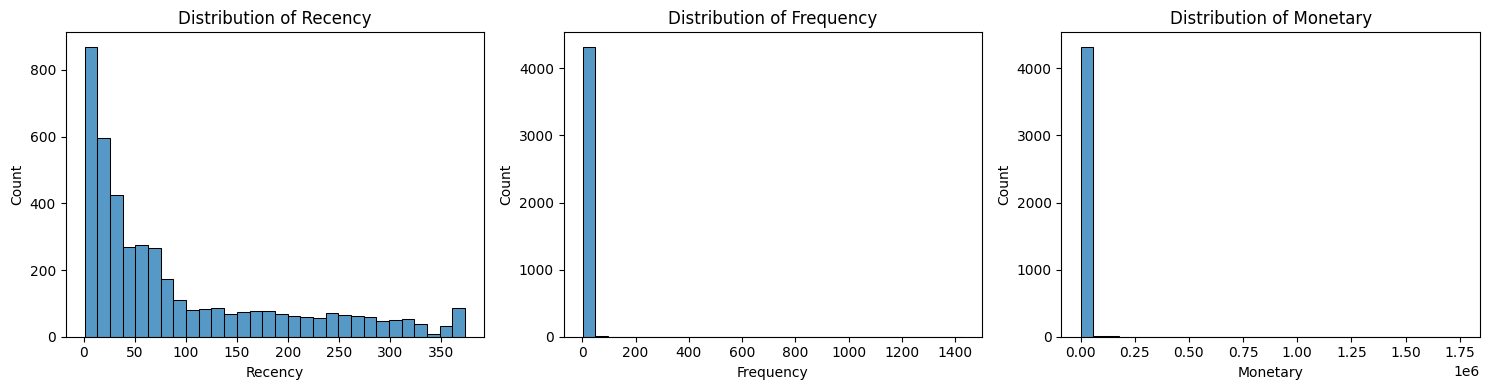

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Recency")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Distribution of Frequency")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Distribution of Monetary")

plt.tight_layout()
plt.show()

In [20]:
frequency_99 = rfm["Frequency"].quantile(0.99)
monetary_99 = rfm["Monetary"].quantile(0.99)

print("Frequency 99th percentile:", frequency_99)
print("Monetary 99th percentile:", monetary_99)

Frequency 99th percentile: 30.0
Monetary 99th percentile: 20095.434800000054


Since the original Frequency and Monetary distributions are compressed by a small number of very large values, the lower 99% will be visualised separately to examine the main customer distribution more clearly. This filtering is only applied to the visualisation and does not remove customers from the modelling dataset.

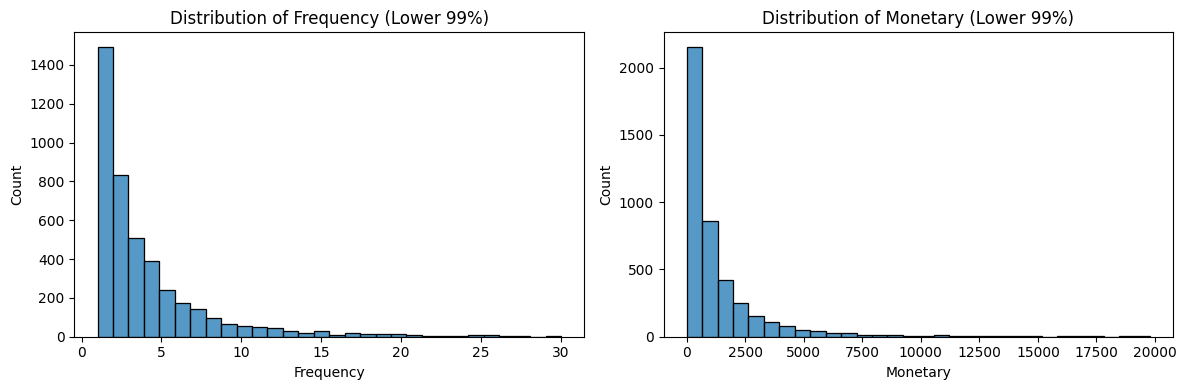

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(rfm[rfm["Frequency"] <= frequency_99]["Frequency"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Frequency (Lower 99%)")

sns.histplot(rfm[rfm["Monetary"] <= monetary_99]["Monetary"], bins=30, ax=axes[1])
axes[1].set_title("Distribution of Monetary (Lower 99%)")

plt.tight_layout()
plt.show()

The focused distributions show that Frequency and Monetary remain strongly right-skewed even when the upper 1% of values are excluded from the visualisation. Most customers make a small number of transactions and generate relatively low total revenue, while progressively fewer customers have higher Frequency and Monetary values.

The descriptive statistics also showed large differences in scale between the three RFM features. Therefore, the features will need to be prepared before applying K-Means clustering so that extreme values and differences in scale do not have too much influence on the model.